# Phase 1 — Baseline Model (Model A)

This notebook reproduces the baseline LightGBM credit default prediction model from the reference notebook for the Barclays BNPL PoC. The data is Home Credit Default Risk from Kaggle.

In [1]:
# ── LLM Configuration ──────────────────────────────────────────────────────
# Model is set via GEMINI_MODEL in ../.env
# Supported: gemini-3.1-flash-image-preview | gemini-3-pro-image-preview
# (Not used in this notebook — baseline is purely structured data.)
# ───────────────────────────────────────────────────────────────────────────

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
import pickle
import warnings
warnings.filterwarnings('ignore')

## Data Loading

In [3]:
app_train = pd.read_csv('../datasets/application_train.csv')
app_test = pd.read_csv('../datasets/application_test.csv')

print('Training data shape: ', app_train.shape)
print('Testing data shape: ', app_test.shape)
app_train.head()

Training data shape:  (307511, 122)
Testing data shape:  (48744, 121)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## EDA Summary

In [4]:
print('Target distribution:')
print(app_train['TARGET'].value_counts())
print(f'\nTarget=1 rate: {app_train["TARGET"].mean():.4f}')

missing = app_train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'\nColumns with missing values: {len(missing)}')
print(missing.head(20))

Target distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target=1 rate: 0.0807

Columns with missing values: 67
COMMONAREA_MEDI             214865
COMMONAREA_AVG              214865
COMMONAREA_MODE             214865
NONLIVINGAPARTMENTS_MEDI    213514
NONLIVINGAPARTMENTS_MODE    213514
NONLIVINGAPARTMENTS_AVG     213514
FONDKAPREMONT_MODE          210295
LIVINGAPARTMENTS_MODE       210199
LIVINGAPARTMENTS_MEDI       210199
LIVINGAPARTMENTS_AVG        210199
FLOORSMIN_MODE              208642
FLOORSMIN_MEDI              208642
FLOORSMIN_AVG               208642
YEARS_BUILD_MODE            204488
YEARS_BUILD_MEDI            204488
YEARS_BUILD_AVG             204488
OWN_CAR_AGE                 202929
LANDAREA_AVG                182590
LANDAREA_MEDI               182590
LANDAREA_MODE               182590
dtype: int64


## Preprocessing

In [5]:
le = LabelEncoder()
le_count = 0

for col in app_train:
    if app_train[col].dtype == 'object':
        if len(list(app_train[col].unique())) <= 2:
            le.fit(app_train[col])
            app_train[col] = le.transform(app_train[col])
            app_test[col] = le.transform(app_test[col])
            le_count += 1

print('%d columns were label encoded.' % le_count)

3 columns were label encoded.


In [6]:
app_train = pd.get_dummies(app_train)
app_test = pd.get_dummies(app_test)

print('Training Features shape: ', app_train.shape)
print('Testing Features shape: ', app_test.shape)

train_labels = app_train['TARGET']
app_train, app_test = app_train.align(app_test, join='inner', axis=1)
app_train['TARGET'] = train_labels

print('Training Features shape (after align): ', app_train.shape)
print('Testing Features shape (after align): ', app_test.shape)

Training Features shape:  (307511, 243)
Testing Features shape:  (48744, 239)
Training Features shape (after align):  (307511, 240)
Testing Features shape (after align):  (48744, 239)


In [7]:
app_train['DAYS_EMPLOYED_ANOM'] = app_train["DAYS_EMPLOYED"] == 365243
app_train['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace=True)

app_test['DAYS_EMPLOYED_ANOM'] = app_test["DAYS_EMPLOYED"] == 365243
app_test["DAYS_EMPLOYED"].replace({365243: np.nan}, inplace=True)

print('Training anomalies: %d out of %d' % (app_train["DAYS_EMPLOYED_ANOM"].sum(), len(app_train)))
print('Testing anomalies: %d out of %d' % (app_test["DAYS_EMPLOYED_ANOM"].sum(), len(app_test)))

Training anomalies: 55374 out of 307511
Testing anomalies: 9274 out of 48744


## Domain Feature Engineering

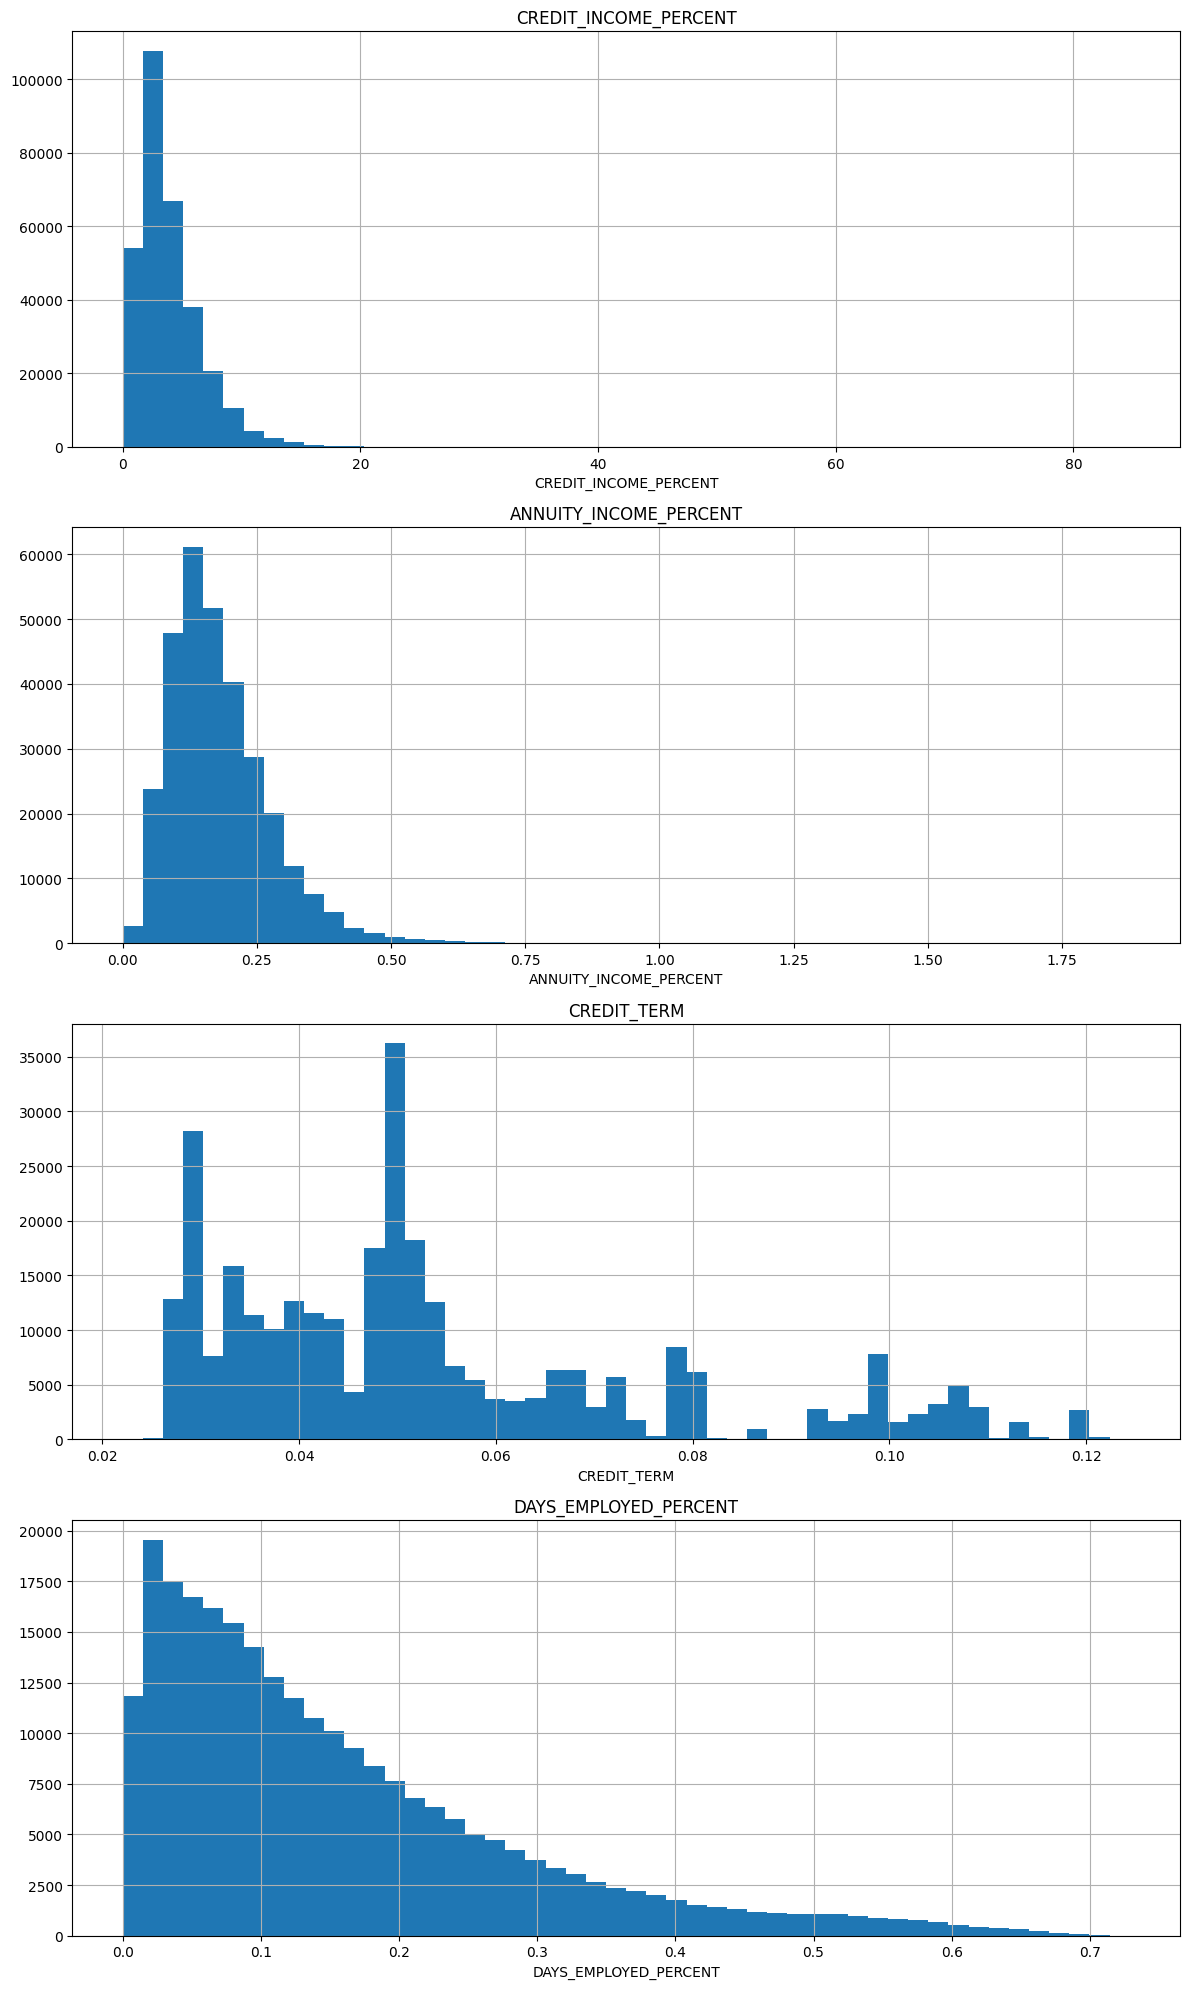

In [8]:
app_train_domain = app_train.copy()
app_test_domain = app_test.copy()

app_train_domain['CREDIT_INCOME_PERCENT'] = app_train_domain['AMT_CREDIT'] / app_train_domain['AMT_INCOME_TOTAL']
app_train_domain['ANNUITY_INCOME_PERCENT'] = app_train_domain['AMT_ANNUITY'] / app_train_domain['AMT_INCOME_TOTAL']
app_train_domain['CREDIT_TERM'] = app_train_domain['AMT_ANNUITY'] / app_train_domain['AMT_CREDIT']
app_train_domain['DAYS_EMPLOYED_PERCENT'] = app_train_domain['DAYS_EMPLOYED'] / app_train_domain['DAYS_BIRTH']

app_test_domain['CREDIT_INCOME_PERCENT'] = app_test_domain['AMT_CREDIT'] / app_test_domain['AMT_INCOME_TOTAL']
app_test_domain['ANNUITY_INCOME_PERCENT'] = app_test_domain['AMT_ANNUITY'] / app_test_domain['AMT_INCOME_TOTAL']
app_test_domain['CREDIT_TERM'] = app_test_domain['AMT_ANNUITY'] / app_test_domain['AMT_CREDIT']
app_test_domain['DAYS_EMPLOYED_PERCENT'] = app_test_domain['DAYS_EMPLOYED'] / app_test_domain['DAYS_BIRTH']

plt.figure(figsize=(12, 20))
for i, feature in enumerate(['CREDIT_INCOME_PERCENT', 'ANNUITY_INCOME_PERCENT', 'CREDIT_TERM', 'DAYS_EMPLOYED_PERCENT']):
    plt.subplot(4, 1, i + 1)
    app_train_domain[feature].hist(bins=50)
    plt.title(feature)
    plt.xlabel(feature)
plt.tight_layout()
plt.show()

## LightGBM Model with 5-Fold Cross-Validation

In [9]:
def model(features, test_features, encoding='ohe', n_folds=5):
    """Train and test a LightGBM model using cross validation."""
    train_ids = features['SK_ID_CURR']
    test_ids = test_features['SK_ID_CURR']
    labels = features['TARGET']
    
    features = features.drop(columns=['SK_ID_CURR', 'TARGET'])
    test_features = test_features.drop(columns=['SK_ID_CURR'])
    
    if encoding == 'ohe':
        features = pd.get_dummies(features)
        test_features = pd.get_dummies(test_features)
        features, test_features = features.align(test_features, join='inner', axis=1)
        cat_indices = 'auto'
    elif encoding == 'le':
        label_encoder = LabelEncoder()
        cat_indices = []
        for i, col in enumerate(features):
            if features[col].dtype == 'object':
                features[col] = label_encoder.fit_transform(np.array(features[col].astype(str)).reshape((-1,)))
                test_features[col] = label_encoder.transform(np.array(test_features[col].astype(str)).reshape((-1,)))
                cat_indices.append(i)
    else:
        raise ValueError("Encoding must be either 'ohe' or 'le'")
    
    print('Training Data Shape: ', features.shape)
    print('Testing Data Shape: ', test_features.shape)
    
    feature_names = list(features.columns)
    features = np.array(features)
    test_features = np.array(test_features)
    
    k_fold = KFold(n_splits=n_folds, shuffle=True, random_state=50)
    feature_importance_values = np.zeros(len(feature_names))
    test_predictions = np.zeros(test_features.shape[0])
    out_of_fold = np.zeros(features.shape[0])
    
    valid_scores = []
    train_scores = []
    
    for train_indices, valid_indices in k_fold.split(features):
        train_features, train_labels = features[train_indices], labels[train_indices]
        valid_features, valid_labels = features[valid_indices], labels[valid_indices]
        
        clf = lgb.LGBMClassifier(
            n_estimators=10000, objective='binary',
            class_weight='balanced', learning_rate=0.05,
            reg_alpha=0.1, reg_lambda=0.1,
            subsample=0.8, n_jobs=-1, random_state=50
        )
        
        clf.fit(train_features, train_labels, eval_metric='auc',
                eval_set=[(valid_features, valid_labels), (train_features, train_labels)],
                eval_names=['valid', 'train'], categorical_feature=cat_indices,
                callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)])
        
        best_iteration = clf.best_iteration_
        feature_importance_values += clf.feature_importances_ / k_fold.n_splits
        test_predictions += clf.predict_proba(test_features, num_iteration=best_iteration)[:, 1] / k_fold.n_splits
        out_of_fold[valid_indices] = clf.predict_proba(valid_features, num_iteration=best_iteration)[:, 1]
        
        valid_score = clf.best_score_['valid']['auc']
        train_score = clf.best_score_['train']['auc']
        valid_scores.append(valid_score)
        train_scores.append(train_score)
        
        gc.enable()
        del clf, train_features, valid_features
        gc.collect()
    
    submission = pd.DataFrame({'SK_ID_CURR': test_ids, 'TARGET': test_predictions})
    feature_importances = pd.DataFrame({'feature': feature_names, 'importance': feature_importance_values})
    
    valid_auc = roc_auc_score(labels, out_of_fold)
    valid_scores.append(valid_auc)
    train_scores.append(np.mean(train_scores))
    
    fold_names = list(range(n_folds))
    fold_names.append('overall')
    
    metrics = pd.DataFrame({'fold': fold_names, 'train': train_scores, 'valid': valid_scores})
    
    return submission, feature_importances, metrics


def plot_feature_importances(df):
    """Plot top-20 feature importances."""
    df = df.sort_values('importance', ascending=False).reset_index(drop=True)
    df_top = df.head(20)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(range(len(df_top)), df_top['importance'], align='center')
    ax.set_yticks(range(len(df_top)))
    ax.set_yticklabels(df_top['feature'])
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance')
    ax.set_title('Top 20 Feature Importances')
    plt.tight_layout()
    plt.show()
    
    return df

## Train Model A (with domain features)

In [10]:
app_train_domain['TARGET'] = train_labels

submission_domain, fi_domain, metrics_domain = model(app_train_domain, app_test_domain)
print('Model A — Baseline with domain knowledge features:')
print(metrics_domain)

Training Data Shape:  (307511, 243)
Testing Data Shape:  (48744, 243)


[LightGBM] [Info] Number of positive: 19919, number of negative: 226089
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.031728 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12493
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 236


[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 100 rounds


[200]	train's auc: 0.804638	train's binary_logloss: 0.541485	valid's auc: 0.762105	valid's binary_logloss: 0.557539


Early stopping, best iteration is:
[245]	train's auc: 0.811955	train's binary_logloss: 0.533946	valid's auc: 0.762655	valid's binary_logloss: 0.552882


...

[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Training until validation scores don't improve for 100 rounds


[200]	train's auc: 0.804506	train's binary_logloss: 0.541655	valid's auc: 0.765112	valid's binary_logloss: 0.559012


[400]	train's auc: 0.834833	train's binary_logloss: 0.510759	valid's auc: 0.765415	valid's binary_logloss: 0.540084


Early stopping, best iteration is:
[392]	train's auc: 0.833826	train's binary_logloss: 0.511812	valid's auc: 0.765478	valid's binary_logloss: 0.540712


Model A — Baseline with domain knowledge features:
      fold     train     valid
0        0  0.811955  0.762655
1        1  0.807738  0.766053
2        2  0.818211  0.770140
3        3  0.817157  0.765712
4        4  0.833826  0.765478
5  overall  0.817777  0.765949


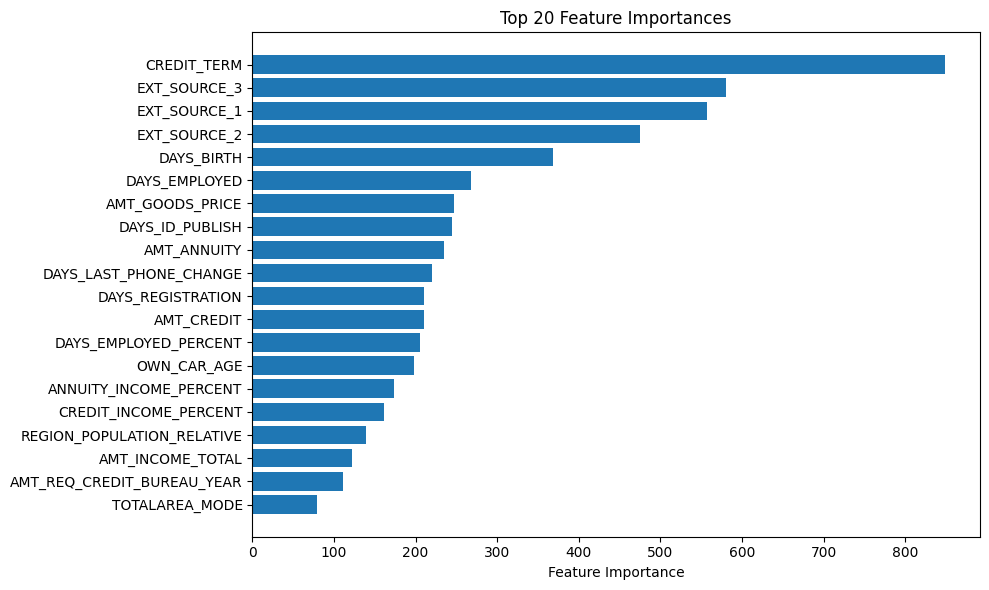

In [11]:
fi_sorted = plot_feature_importances(fi_domain)

## Save Model A Artifacts

In [12]:
model_a_auc = metrics_domain[metrics_domain['fold'] == 'overall']['valid'].values[0]
print(f'Model A Validation ROC-AUC (benchmark): {model_a_auc:.6f}')

os.makedirs('../artifacts', exist_ok=True)

metrics_domain.to_csv('../artifacts/model_a_metrics.csv', index=False)
fi_domain.to_csv('../artifacts/model_a_feature_importances.csv', index=False)
submission_domain.to_csv('../artifacts/model_a_submission.csv', index=False)

with open('../artifacts/model_a_auc.txt', 'w') as f:
    f.write(str(model_a_auc))

print('Model A artifacts saved to ../artifacts/')

Model A Validation ROC-AUC (benchmark): 0.765949
Model A artifacts saved to ../artifacts/
